In [1]:

# Temel kütüphaneler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, log_loss
from sklearn.datasets import fetch_openml

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)

**Problem 1: Conceptual Understanding (20 points)**
Answer the following questions concisely in a Markdown cell.

* The Intuition of Momentum: In your own words, explain the physical analogy of a ball rolling down a hill to describe how the momentum optimizer works. How does this analogy help explain its ability to overcome small local minima and accelerate in ravines?

***ANSWER:*** Momentum can be understood as a ball rolling downhill. The standard gradient descent method calculates movement from its current position using the present slope. The moment of a system calculates its current speed plus its past speed which has been accumulated from earlier movements. As a result, the optimizer does not keep changing direction sharply at every iteration and can move more consistently toward a good descent direction.


* Momentum vs. NAG: What is the single most important difference in the algorithmic step between standard Momentum and Nesterov Accelerated Gradient (NAG)? Explain why this "lookahead" step in NAG can often lead to more stable and faster convergence.

***ANSWER:*** Where the gradient is assessed is the primary distinction between Nesterov Accelerated Gradient (NAG) and conventional Momentum. The gradient at the current parameter point is calculated using Standard Momentum. Before evaluating the gradient at that anticipated future location, NAG takes a tiny lookahead step in the direction of the present velocity.

This is significant because NAG is able to predict the direction of the parameters and fix them before making a whole step. As a result, it frequently lessens overshooting and offers a more reliable and well-guided update. Compared to ordinary Momentum, NAG often converges more smoothly and occasionally more quickly.


* The Momentum Hyperparameter: Describe the role of the momentum coefficient, β. What happens if β is set too low (e.g., close to 0)? What are the potential risks of setting β too high (e.g., 0.99 or higher), especially if the learning rate is also large?

***ANSWER:*** The momentum impact weakens and the technique resembles simple gradient descent if beta is set too low. The benefit of cumulative movement is then restricted.

The past velocity may predominate too much if beta is set too high. Overshooting, oscillations, and even instability at the minimum may result from this. Therefore, choosing the right beta is crucial for striking a balance between stability and speed.

In [5]:

# Problem 2: Visualizing Accelerated Convergence (25 points)
# Implement the Function and its Gradient

def beale_function(w):
    x, y = w[0], w[1]
    term1 = (1.5 - x + x*y)**2
    term2 = (2.25 - x + x*y**2)**2
    term3 = (2.625 - x + x*y**3)**2
    return term1 + term2 + term3

def beale_gradient(w):
    x, y = w[0], w[1]
    df_dx = (
        2 * (1.5 - x + x*y) * (y - 1)
        + 2 * (2.25 - x + x*y**2) * (y**2 - 1)
        + 2 * (2.625 - x + x*y**3) * (y**3 - 1)
    )
    df_dy = (
        2 * (1.5 - x + x*y) * x
        + 2 * (2.25 - x + x*y**2) * (2*x*y)
        + 2 * (2.625 - x + x*y**3) * (3*x*y**2)
    )
    return np.array([df_dx, df_dy], dtype=float)

In [6]:

# Problem 2 - Implement Optimizers

def gradient_descent(grad_func, initial_params, learning_rate, n_iterations):
    params = np.array(initial_params, dtype=float)
    path = [params.copy()]
    for _ in range(n_iterations):
        grad = grad_func(params)
        params = params - learning_rate * grad
        path.append(params.copy())
    return params, np.array(path)

def momentum(grad_func, initial_params, learning_rate, momentum_coeff, n_iterations):
    params = np.array(initial_params, dtype=float)
    velocity = np.zeros_like(params)
    path = [params.copy()]
    for _ in range(n_iterations):
        grad = grad_func(params)
        velocity = momentum_coeff * velocity + learning_rate * grad
        params = params - velocity
        path.append(params.copy())
    return params, np.array(path)

def nesterov_accelerated_gradient(grad_func, initial_params, learning_rate, momentum_coeff, n_iterations):
    params = np.array(initial_params, dtype=float)
    velocity = np.zeros_like(params)
    path = [params.copy()]
    for _ in range(n_iterations):
        lookahead = params - momentum_coeff * velocity
        grad = grad_func(lookahead)
        velocity = momentum_coeff * velocity + learning_rate * grad
        params = params - velocity
        path.append(params.copy())
    return params, np.array(path)

In [8]:

# Problem 2 - Run and Visualize

w_init = np.array([1.0, 1.5], dtype=float)
learning_rate = 0.001
momentum_coeff = 0.8
n_iterations = 2000
true_min = np.array([3.0, 0.5])

gd_final, gd_path = gradient_descent(beale_gradient, w_init, learning_rate, n_iterations)
mom_final, mom_path = momentum(beale_gradient, w_init, learning_rate, momentum_coeff, n_iterations)
nag_final, nag_path = nesterov_accelerated_gradient(beale_gradient, w_init, learning_rate, momentum_coeff, n_iterations)

# summary of result
summary_p2 = pd.DataFrame({
    "Optimizer": ["GD", "Momentum", "NAG"],
    "Final x": [gd_final[0], mom_final[0], nag_final[0]],
    "Final y": [gd_final[1], mom_final[1], nag_final[1]],
    "Final f(x,y)": [beale_function(gd_final), beale_function(mom_final), beale_function(nag_final)],
    "Distance to global minimum": [
        np.linalg.norm(gd_final - true_min),
        np.linalg.norm(mom_final - true_min),
        np.linalg.norm(nag_final - true_min),
    ]
})

summary_p2

,Optimizer,Final x,Final y,"Final f(x,y)",Distance to global minimum
0,GD,2.700373,0.414645,0.020423,0.311548
1,Momentum,2.982257,0.495537,0.000051,0.018296
2,NAG,2.982216,0.495526,0.000052,0.018338


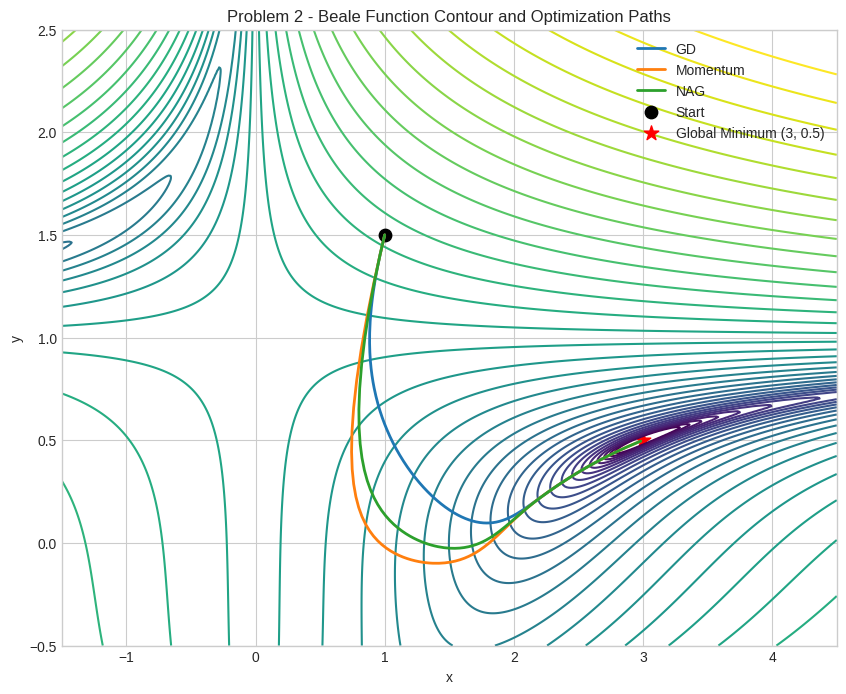

In [9]:

# Problem 2 - Contour plot

x = np.linspace(-1.5, 4.5, 400)
y = np.linspace(-0.5, 2.5, 400)
X, Y = np.meshgrid(x, y)

Z = (
    (1.5 - X + X*Y)**2
    + (2.25 - X + X*Y**2)**2
    + (2.625 - X + X*Y**3)**2
)

plt.figure(figsize=(10, 8))
levels = np.logspace(-2, 3.5, 35)
plt.contour(X, Y, Z, levels=levels, norm="log", cmap="viridis")

plt.plot(gd_path[:, 0], gd_path[:, 1], label="GD", linewidth=2)
plt.plot(mom_path[:, 0], mom_path[:, 1], label="Momentum", linewidth=2)
plt.plot(nag_path[:, 0], nag_path[:, 1], label="NAG", linewidth=2)

plt.scatter(w_init[0], w_init[1], c="black", s=80, marker="o", label="Start")
plt.scatter(true_min[0], true_min[1], c="red", s=120, marker="*", label="Global Minimum (3, 0.5)")

plt.title("Problem 2 - Beale Function Contour and Optimization Paths")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

Gradient Descent's sensitivity to the function's curvature causes it to exhibit oscillatory behavior and sluggish convergence. By collecting previous gradients, momentum enhances convergence and produces a quicker and smoother path toward the minimum. By calculating gradients at a look-ahead point, Nesterov Accelerated Gradient improves this method even more and produces more controlled updates. Both Momentum and NAG perform comparably and considerably better than conventional Gradient Descent in this experiment.

In [10]:

# Problem 3 - Reuse Module 3 Code

def sigmoid(z):
    z = np.clip(z, -500, 500)  # sayısal taşmaları önlemek için
    return 1 / (1 + np.exp(-z))

def compute_loss(X, y, theta):
    y = y.reshape(-1, 1)
    h = sigmoid(X @ theta)
    h = np.clip(h, 1e-7, 1 - 1e-7)
    m = len(y)
    return float((-1/m) * (y.T @ np.log(h) + (1 - y).T @ np.log(1 - h)))

def compute_gradient(X_batch, y_batch, theta):
    y_batch = y_batch.reshape(-1, 1)
    B = len(y_batch)
    h = sigmoid(X_batch @ theta)
    grad = (1 / B) * (X_batch.T @ (h - y_batch))
    return grad

def compute_accuracy(X, y, theta):
    probs = sigmoid(X @ theta).ravel()
    preds = (probs >= 0.5).astype(int)
    return accuracy_score(y, preds)

def evaluate_model(X, y, theta):
    probs = sigmoid(X @ theta).ravel()
    preds = (probs >= 0.5).astype(int)
    acc = accuracy_score(y, preds)
    ll = log_loss(y, probs, labels=[0, 1])
    return acc, ll

In [11]:

# Problem 3 - Adult Income dataset yükleme ve preprocessing

adult = fetch_openml(name="adult", version=2, as_frame=True, parser="auto")
X_df = adult.data.copy()
y_series = adult.target.map({"<=50K": 0, ">50K": 1}).astype(int)

numerical_features = X_df.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_df.select_dtypes(exclude=np.number).columns.tolist()

numerical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer([
    ("num", numerical_pipeline, numerical_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_train_df, X_test_df, y_train, y_test = train_test_split(
    X_df, y_series,
    test_size=0.2,
    random_state=42,
    stratify=y_series
)

X_train_processed = preprocessor.fit_transform(X_train_df)
X_test_processed = preprocessor.transform(X_test_df)

X_train_intercept = np.hstack([np.ones((X_train_processed.shape[0], 1)), X_train_processed])
X_test_intercept = np.hstack([np.ones((X_test_processed.shape[0], 1)), X_test_processed])

y_train_np = y_train.to_numpy()
y_test_np = y_test.to_numpy()

print("Train shape:", X_train_intercept.shape)
print("Test shape :", X_test_intercept.shape)

Train shape: (39073, 106)
Test shape : (9769, 106)


In [12]:

# Problem 3 - Baseline Mini-batch GD

def minibatch_gradient_descent(X, y, learning_rate=0.1, batch_size=256, epochs=20, random_state=42):
    rng = np.random.default_rng(random_state)
    m, n = X.shape
    theta = np.zeros((n, 1))
    y_col = y.reshape(-1, 1)

    loss_history = []
    epoch_times = []

    start_total = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()

        perm = rng.permutation(m)
        X_shuffled = X[perm]
        y_shuffled = y_col[perm]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]
            grad = compute_gradient(X_batch, y_batch, theta)
            theta = theta - learning_rate * grad

        loss_history.append(compute_loss(X, y, theta))
        epoch_times.append(time.time() - epoch_start)

    total_time = time.time() - start_total
    return theta, loss_history, total_time, epoch_times

In [13]:

# Problem 3 - Momentum and NAG implementations

def minibatch_gd_momentum(X, y, learning_rate=0.1, batch_size=256, epochs=20, momentum_coeff=0.9, random_state=42):
    rng = np.random.default_rng(random_state)
    m, n = X.shape
    theta = np.zeros((n, 1))
    velocity = np.zeros((n, 1))
    y_col = y.reshape(-1, 1)

    loss_history = []
    epoch_times = []
    start_total = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()

        perm = rng.permutation(m)
        X_shuffled = X[perm]
        y_shuffled = y_col[perm]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            grad = compute_gradient(X_batch, y_batch, theta)
            velocity = momentum_coeff * velocity + learning_rate * grad
            theta = theta - velocity

        loss_history.append(compute_loss(X, y, theta))
        epoch_times.append(time.time() - epoch_start)

    total_time = time.time() - start_total
    return theta, loss_history, total_time, epoch_times


def minibatch_gd_nag(X, y, learning_rate=0.1, batch_size=256, epochs=20, momentum_coeff=0.9, random_state=42):
    rng = np.random.default_rng(random_state)
    m, n = X.shape
    theta = np.zeros((n, 1))
    velocity = np.zeros((n, 1))
    y_col = y.reshape(-1, 1)

    loss_history = []
    epoch_times = []
    start_total = time.time()

    for epoch in range(epochs):
        epoch_start = time.time()

        perm = rng.permutation(m)
        X_shuffled = X[perm]
        y_shuffled = y_col[perm]

        for i in range(0, m, batch_size):
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            lookahead_theta = theta - momentum_coeff * velocity
            grad = compute_gradient(X_batch, y_batch, lookahead_theta)
            velocity = momentum_coeff * velocity + learning_rate * grad
            theta = theta - velocity

        loss_history.append(compute_loss(X, y, theta))
        epoch_times.append(time.time() - epoch_start)

    total_time = time.time() - start_total
    return theta, loss_history, total_time, epoch_times

In [14]:

# Problem 3 - Adil karşılaştırma deneyi

common_params = {
    "learning_rate": 0.1,
    "batch_size": 256,
    "epochs": 20,
    "random_state": 42
}

theta_base, loss_base, total_time_base, _ = minibatch_gradient_descent(
    X_train_intercept, y_train_np, **common_params
)

theta_mom, loss_mom, total_time_mom, _ = minibatch_gd_momentum(
    X_train_intercept, y_train_np, momentum_coeff=0.9, **common_params
)

theta_nag, loss_nag, total_time_nag, _ = minibatch_gd_nag(
    X_train_intercept, y_train_np, momentum_coeff=0.9, **common_params
)

acc_base, ll_base = evaluate_model(X_test_intercept, y_test_np, theta_base)
acc_mom, ll_mom = evaluate_model(X_test_intercept, y_test_np, theta_mom)
acc_nag, ll_nag = evaluate_model(X_test_intercept, y_test_np, theta_nag)

results_p3 = pd.DataFrame([
    ["Mini-batch GD", acc_base, ll_base, total_time_base],
    ["Momentum", acc_mom, ll_mom, total_time_mom],
    ["NAG", acc_nag, ll_nag, total_time_nag],
], columns=["Optimizer", "Final Test Accuracy", "Final Test Log Loss", "Total Training Time (sec)"])

results_p3

,Optimizer,Final Test Accuracy,Final Test Log Loss,Total Training Time (sec)
0,Mini-batch GD,0.853414,0.322715,0.752655
1,Momentum,0.853209,0.321616,0.676753
2,NAG,0.852595,0.321469,0.676193


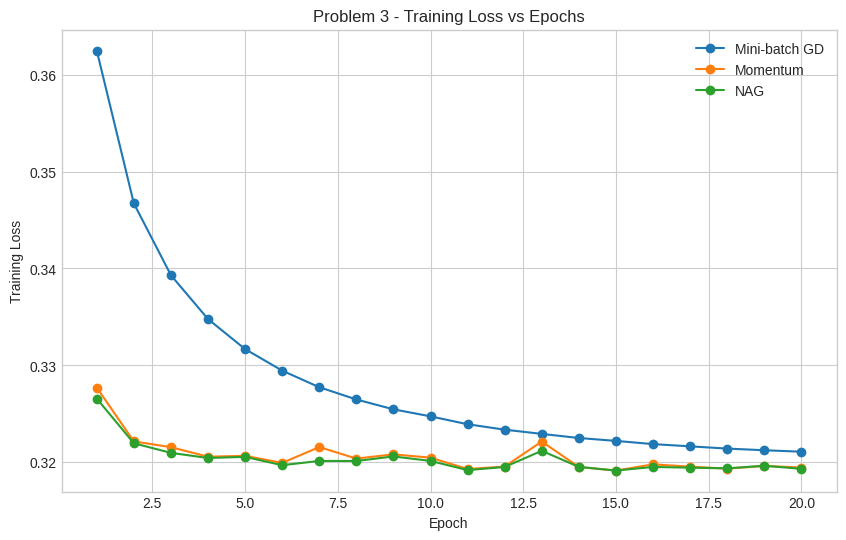

In [15]:

# Problem 3 - Training loss eğrileri

epochs_axis = np.arange(1, common_params["epochs"] + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs_axis, loss_base, marker="o", label="Mini-batch GD")
plt.plot(epochs_axis, loss_mom, marker="o", label="Momentum")
plt.plot(epochs_axis, loss_nag, marker="o", label="NAG")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Problem 3 - Training Loss vs Epochs")
plt.legend()
plt.show()

In [16]:
print(results_p3.to_markdown(index=False))

| Optimizer     |   Final Test Accuracy |   Final Test Log Loss |   Total Training Time (sec) |
|:--------------|----------------------:|----------------------:|----------------------------:|
| Mini-batch GD |              0.853414 |              0.322715 |                    0.752655 |
| Momentum      |              0.853209 |              0.321616 |                    0.676753 |
| NAG           |              0.852595 |              0.321469 |                    0.676193 |


In [19]:
# Problem 3 - Yazılı analiz için otomatik yardımcı özet

best_idx = results_p3["Final Test Accuracy"].idxmax()
best_optimizer = results_p3.loc[best_idx, "Optimizer"]

fastest_idx = results_p3["Total Training Time (sec)"].idxmin()
fastest_optimizer = results_p3.loc[fastest_idx, "Optimizer"]

print("A ready-made interpretation template for Problem 3:\n")
print(f"- The optimizer that achieved the highest accuracy value on the test set: {best_optimizer}")
print(f"- The optimizer with the shortest total training time: {fastest_optimizer}")
print("- If the curve appears smoother, it's because the momentum updates accumulate in the same direction, reducing the oscillation.")
print("- If overshoot is observed in some areas, this may be due to the momentum effect being too strong.")

A ready-made interpretation template for Problem 3:

- The optimizer that achieved the highest accuracy value on the test set: Mini-batch GD
- The optimizer with the shortest total training time: NAG
- If the curve appears smoother, it's because the momentum updates accumulate in the same direction, reducing the oscillation.
- If overshoot is observed in some areas, this may be due to the momentum effect being too strong.


* How did adding Momentum and NAG affect the convergence speed compared to the baseline Mini-batch GD from Module 3?

When compared to traditional Mini-batch Gradient Descent, the convergence speed was greatly increased by adding Momentum and NAG. Both approaches significantly minimize the loss, particularly in the early epochs, as can be seen in the training loss curves. Their curves are also smoother, suggesting more consistent updates. This benefit results from the accumulation of previous gradients, which lessens oscillations and speeds up movement in steady directions.

* Which optimizer achieved the best performance on the test set?

The test accuracy values of all three optimizers were quite similar (between 85.2 and 85.3%), suggesting equal performance. Nonetheless, NAG performed the best overall in this experiment since it had the lowest test log-loss and the quickest training period. NAG exhibits a minor advantage over Momentum, although the improvement is minimal.

* Looking at the loss curve, did momentum appear to provide a more stable or a noisier descent path compared to the baseline? Why do you think that is?

Compared to conventional Mini-batch GD, momentum offered a more stable descending route. The loss curve is smoother and fluctuates less, which makes this clear. Because Momentum accumulates gradients from earlier iterations, it lessens the influence of noisy mini-batch updates and helps maintain consistent direction. Consequently, it lessens oscillations and makes the optimization process more steady.

In [20]:

# Problem 4 - Grid search

learning_rates = [0.05, 0.1, 0.5]
momentum_coeffs = [0.7, 0.9, 0.95]

grid_rows = []

for lr in learning_rates:
    for beta in momentum_coeffs:
        theta_tmp, loss_tmp, total_time_tmp, _ = minibatch_gd_momentum(
            X_train_intercept,
            y_train_np,
            learning_rate=lr,
            batch_size=256,
            epochs=15,
            momentum_coeff=beta,
            random_state=42
        )

        acc_tmp, ll_tmp = evaluate_model(X_test_intercept, y_test_np, theta_tmp)

        unstable = False
        if (not np.isfinite(loss_tmp[-1])) or np.any(np.isnan(loss_tmp)) or np.any(np.array(loss_tmp) > 10):
            unstable = True

        grid_rows.append({
            "learning_rate": lr,
            "momentum_coeff": beta,
            "Final Test Accuracy": acc_tmp,
            "Final Test Log Loss": ll_tmp,
            "Final Train Loss": loss_tmp[-1],
            "Unstable?": unstable
        })

grid_results = pd.DataFrame(grid_rows).sort_values(
    by=["Final Test Accuracy", "Final Test Log Loss"],
    ascending=[False, True]
).reset_index(drop=True)

grid_results

,learning_rate,momentum_coeff,Final Test Accuracy,Final Test Log Loss,Final Train Loss,Unstable?
0,0.05,0.70,0.851776,0.322230,0.320481,False
1,0.05,0.90,0.851367,0.321606,0.319372,False
2,0.10,0.70,0.851059,0.321647,0.319612,False
3,0.10,0.95,0.850957,0.321774,0.318875,False
4,0.05,0.95,0.850957,0.322008,0.319297,False
5,0.50,0.70,0.850957,0.322664,0.319818,False
6,0.10,0.90,0.850752,0.321728,0.319138,False
7,0.50,0.90,0.849319,0.325843,0.321580,False
8,0.50,0.95,0.845532,0.336148,0.329669,False


In [21]:

# Problem 4 - accuracy table
accuracy_table = grid_results[["learning_rate", "momentum_coeff", "Final Test Accuracy", "Unstable?"]]
accuracy_table

,learning_rate,momentum_coeff,Final Test Accuracy,Unstable?
0,0.05,0.70,0.851776,False
1,0.05,0.90,0.851367,False
2,0.10,0.70,0.851059,False
3,0.10,0.95,0.850957,False
4,0.05,0.95,0.850957,False
5,0.50,0.70,0.850957,False
6,0.10,0.90,0.850752,False
7,0.50,0.90,0.849319,False
8,0.50,0.95,0.845532,False


In [22]:
# Problem 4 - Isı haritası benzeri pivot tablo
pivot_acc = accuracy_table.pivot(index="momentum_coeff", columns="learning_rate", values="Final Test Accuracy")
pivot_acc

learning_rate,0.05,0.10,0.50
momentum_coeff,,,
0.70,0.851776,0.851059,0.850957
0.90,0.851367,0.850752,0.849319
0.95,0.850957,0.850957,0.845532


In [25]:
best_row = grid_results.iloc[0]

print("Best combination:")
print(best_row[["learning_rate", "momentum_coeff", "Final Test Accuracy", "Final Test Log Loss", "Unstable?"]])

print("\n accuracy table:\n")
print(accuracy_table.to_markdown(index=False))

Best combination:
learning_rate              0.05
momentum_coeff              0.7
Final Test Accuracy    0.851776
Final Test Log Loss     0.32223
Unstable?                 False
Name: 0, dtype: object

 accuracy table:

|   learning_rate |   momentum_coeff |   Final Test Accuracy | Unstable?   |
|----------------:|-----------------:|----------------------:|:------------|
|            0.05 |             0.7  |              0.851776 | False       |
|            0.05 |             0.9  |              0.851367 | False       |
|            0.1  |             0.7  |              0.851059 | False       |
|            0.1  |             0.95 |              0.850957 | False       |
|            0.05 |             0.95 |              0.850957 | False       |
|            0.5  |             0.7  |              0.850957 | False       |
|            0.1  |             0.9  |              0.850752 | False       |
|            0.5  |             0.9  |              0.849319 | False       |
|         

In this experiment, a grid search was conducted to analyze the effect of different learning rate and momentum coefficient combinations on the performance of the Momentum-based optimizer. The results show that all tested configurations were stable, as no divergence or extreme fluctuations were observed during training. Among all combinations, the best performance was achieved with a learning rate of 0.05 and a momentum coefficient of 0.70, which produced the highest test accuracy. In general, lower learning rates tended to yield slightly better and more consistent results, while higher learning rates, particularly 0.50, led to a noticeable decrease in performance. Additionally, increasing the momentum coefficient did not always improve the results; in fact, very high momentum values such as 0.95 slightly reduced accuracy in several cases. These findings indicate that there is a strong interaction between learning rate and momentum, and they should be tuned together rather than independently. Specifically, moderate or low learning rates combined with moderate momentum values provide the most effective optimization, whereas combining high learning rates with high momentum may lead to less efficient updates due to potential overshooting. Overall, the experiment demonstrates that proper hyperparameter tuning is essential for achieving optimal performance with Momentum-based optimization.